## 02. 데이터 1차 전처리 및 EDA


### 작업 순서

1. 변수명 및 데이터 타입 정리&변환
2. 중복·결측·이상값 점검
3. 기본 파생변수 생성
4. 정제 결과 검증
5. 계약 유형 및 지역별 표본 구성
6. 전월세 환산보증금 산출
7. 면적 구간 및 면적당가격 분석
8. 이상치 탐지 및 처리


In [5]:
import pandas as pd

df = pd.read_csv('dataset_ML1조.csv')

## 1. 변수명 및 데이터 타입 정리&변환

*   '영문' -> '한글' 번역 정리



In [ ]:
COLUMN_NAME_MAP = {
    "buildYear": "건축년도",
    "contractTerm": "계약기간",
    "contractType": "계약구분",
    "dealDay": "계약일",
    "dealMonth": "계약월",
    "dealYear": "계약연도",
    "deposit": "보증금_만원",
    "excluUseAr": "전용면적_m2",
    "floor": "층",
    "houseType": "주택유형",
    "jibun": "지번",
    "mhouseNm": "건물명",
    "monthlyRent": "월세금_만원",
    "preDeposit": "종전보증금_만원",
    "preMonthlyRent": "종전월세_만원",
    "sggCd": "법정동코드",
    "umdNm": "읍면동",
    "useRRRight": "갱신요구권사용"
}

df = df.rename(columns=COLUMN_NAME_MAP)

print("변경 후 컬럼")
print(df.columns.tolist())

변경 후 컬럼
['건축년도', '계약기간', '계약구분', '계약일', '계약월', '계약연도', '보증금_만원', '전용면적_m2', '층', '주택유형', '지번', '건물명', '월세금_만원', '종전보증금_만원', '종전월세_만원', '법정동코드', '읍면동', '갱신요구권사용', '_구', '_조회연월']



*   '문자열' -> '수치형' 변환
*   '쉼표', '공백' 제거



In [ ]:
def convert_to_numeric(series: pd.Series) -> pd.Series:
    """쉼표와 공백을 제거한 뒤 숫자형으로 변환합니다."""
    cleaned = (
        series
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace("", pd.NA)
    )

    return pd.to_numeric(cleaned, errors="coerce")


numeric_columns = [
    "건축년도",
    "계약연도",
    "계약월",
    "계약일",
    "보증금_만원",
    "월세금_만원",
    "종전보증금_만원",
    "종전월세_만원",
    "전용면적_m2",
    "층"
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = convert_to_numeric(df[column])

print("수치형 변수 타입")
display(df[numeric_columns].dtypes.to_frame("dtype"))

수치형 변수 타입


,dtype
건축년도,Int64
계약연도,Int64
계약월,Int64
계약일,Int64
보증금_만원,Int64
월세금_만원,Int64
종전보증금_만원,Int64
종전월세_만원,Int64
전용면적_m2,Float64
층,Int64



*   '`계약일자`' 변수 생성



In [ ]:
df["계약일자"] = pd.to_datetime(
    {
        "year": df["계약연도"],
        "month": df["계약월"],
        "day": df["계약일"]
    },
    errors="coerce"
)

df["계약연월"] = (
    df["계약일자"]
    .dt.to_period("M")
    .astype("string")
)

print("계약일자 결측값:", df["계약일자"].isna().sum())
display(
    df[
        [
            "계약연도",
            "계약월",
            "계약일",
            "계약일자",
            "계약연월"
        ]
    ].head()
)

계약일자 결측값: 0


,계약연도,계약월,계약일,계약일자,계약연월
0,2023,1,7,2023-01-07,2023-01
1,2023,1,23,2023-01-23,2023-01
2,2023,1,1,2023-01-01,2023-01
3,2023,1,27,2023-01-27,2023-01
4,2023,1,20,2023-01-20,2023-01


## 2. 중복·결측·이상값 점검

- 완전히 동일한 중복 행
- 주요 변수의 결측값
- 면적 또는 금액이 0 이하인 관측치
- 계약연도와 조회연월 간 불일치
- 보증금이 0인 월세 계약의 존재 여부

보증금이 0인 계약은 무조건 오류라고 판단하지 않고,  
월세금과 함께 확인하여 실제 무보증 월세일 가능성을 검토함.

In [ ]:
zero_deposit = df[df["보증금_만원"] == 0].copy()

print(f"보증금이 0인 계약: {len(zero_deposit):,}건")

display(
    zero_deposit[
        [
            "_구",
            "읍면동",
            "계약일자",
            "보증금_만원",
            "월세금_만원",
            "전용면적_m2",
            "건물명"
        ]
    ].head(20)
)

보증금이 0인 계약: 71건


,_구,읍면동,계약일자,보증금_만원,월세금_만원,전용면적_m2,건물명
2,성북구,삼선동1가,2023-01-01,0,53,73.32,이정빌라
58,성북구,삼선동1가,2023-01-15,0,55,73.32,이정빌라
61,성북구,삼선동1가,2023-01-15,0,55,73.32,이정빌라
466,성북구,삼선동1가,2023-02-14,0,60,73.32,이정빌라
559,성북구,삼선동1가,2023-02-27,0,55,73.32,이정빌라
560,성북구,삼선동1가,2023-02-25,0,55,79.02,이정빌라
561,성북구,삼선동1가,2023-02-26,0,55,79.02,이정빌라
566,성북구,삼선동1가,2023-02-17,0,55,60.65,이정빌라
951,성북구,정릉동,2023-03-10,0,50,56.79,산장빌라(산87-85)
1002,성북구,장위동,2023-03-13,0,10,38.29,현대빌라


완전히 동일한 행 -> **제거**

다음과 같은 항목 -> **제거**

- 전용면적이 0㎡ 이하인 경우
- 보증금 또는 월세금이 음수인 경우
- 보증금과 월세금이 모두 0인 경우

보증금이 0이더라도 월세금이 양수인 계약은  
무보증 월세일 가능성이 있으므로 일괄 제거 X.

In [ ]:
cleaning_log = []

before = len(df)
df = df.drop_duplicates().copy()
cleaning_log.append({
    "처리내용": "완전 중복 행 제거",
    "처리 전": before,
    "처리 후": len(df),
    "제거 건수": before - len(df)
})

before = len(df)
df = df[df["전용면적_m2"] > 0].copy()
cleaning_log.append({
    "처리내용": "전용면적 0㎡ 이하 제거",
    "처리 전": before,
    "처리 후": len(df),
    "제거 건수": before - len(df)
})

before = len(df)
df = df[
    (df["보증금_만원"] >= 0)
    & (df["월세금_만원"] >= 0)
].copy()
cleaning_log.append({
    "처리내용": "음수 금액 제거",
    "처리 전": before,
    "처리 후": len(df),
    "제거 건수": before - len(df)
})

before = len(df)
df = df[
    ~(
        (df["보증금_만원"] == 0)
        & (df["월세금_만원"] == 0)
    )
].copy()
cleaning_log.append({
    "처리내용": "보증금·월세금 모두 0인 행 제거",
    "처리 전": before,
    "처리 후": len(df),
    "제거 건수": before - len(df)
})

cleaning_log = pd.DataFrame(cleaning_log)

display(cleaning_log)

,처리내용,처리 전,처리 후,제거 건수
0,완전 중복 행 제거,28207,26901,1306
1,전용면적 0㎡ 이하 제거,26901,26901,0
2,음수 금액 제거,26901,26901,0
3,보증금·월세금 모두 0인 행 제거,26901,26901,0


In [ ]:
missing_summary = pd.DataFrame({
    "결측 건수": df.isna().sum(),
    "결측 비율(%)": df.isna().mean() * 100
})

missing_summary = (
    missing_summary
    .sort_values("결측 비율(%)", ascending=False)
)

display(missing_summary.head(20))

,결측 건수,결측 비율(%)
종전월세_만원,25213,93.725140
종전보증금_만원,21596,80.279544
계약구분,0,0.000000
계약일,0,0.000000
건축년도,0,0.000000
계약기간,0,0.000000
계약연도,0,0.000000
계약월,0,0.000000
층,0,0.000000
보증금_만원,0,0.000000


## 3. 기본 파생변수 생성

### 생성 변수

- **전월세구분:** 월세금이 0이면 전세, 0보다 크면 월세
- **주택연령:** 계약연도에서 건축연도를 차감한 값
- **면적구간:** 전용면적에 따른 주택 규모 구분
- **동그룹:** 안암동·보문동 및 기타 지역 구분

In [ ]:
df["전월세구분"] = np.where(
    df["월세금_만원"] == 0,
    "전세",
    "월세"
)

df["주택연령"] = df["계약연도"] - df["건축년도"]

df.loc[
    (df["주택연령"] < 0)
    | (df["주택연령"] > 100),
    "주택연령"
] = np.nan


def classify_area(area: float) -> str:
    if pd.isna(area):
        return pd.NA
    if area <= 20:
        return "20㎡ 이하"
    if area <= 33:
        return "20㎡ 초과~33㎡ 이하"
    return "33㎡ 초과"


def classify_dong(dong: str) -> str:
    if pd.isna(dong):
        return "기타"
    if str(dong).startswith("안암동"):
        return "안암동"
    if str(dong).startswith("보문동"):
        return "보문동"
    return "기타"


df["면적구간"] = df["전용면적_m2"].apply(classify_area)
df["동그룹"] = df["읍면동"].apply(classify_dong)

display(
    df[
        [
            "읍면동",
            "동그룹",
            "전용면적_m2",
            "면적구간",
            "전월세구분",
            "건축년도",
            "주택연령"
        ]
    ].head()
)

,읍면동,동그룹,전용면적_m2,면적구간,전월세구분,건축년도,주택연령
0,장위동,기타,81.298,33㎡ 초과,월세,2020,3
1,안암동1가,안암동,48.84,33㎡ 초과,월세,2001,22
2,삼선동1가,기타,73.32,33㎡ 초과,월세,2008,15
3,장위동,기타,47.24,33㎡ 초과,월세,1978,45
4,삼선동4가,기타,12.25,20㎡ 이하,월세,2010,13


## 4. 정제 결과 검증

In [ ]:
print(f"정제 후 데이터 크기: {df.shape[0]:,}행 × {df.shape[1]:,}열")

print("\n계약연도별 거래 건수")
display(
    df["계약연도"]
    .value_counts()
    .sort_index()
    .rename_axis("계약연도")
    .reset_index(name="거래건수")
)

print("\n자치구별 거래 건수")
display(
    df["_구"]
    .value_counts()
    .rename_axis("자치구")
    .reset_index(name="거래건수")
)

print("\n전월세 구분")
display(
    df["전월세구분"]
    .value_counts(dropna=False)
    .rename_axis("전월세구분")
    .reset_index(name="거래건수")
)

print("\n동그룹별 거래 건수")
display(
    df["동그룹"]
    .value_counts()
    .rename_axis("동그룹")
    .reset_index(name="거래건수")
)

정제 후 데이터 크기: 26,901행 × 26열

계약연도별 거래 건수


,계약연도,거래건수
0,2023,7510
1,2024,7779
2,2025,7380
3,2026,4232



자치구별 거래 건수


,자치구,거래건수
0,성북구,15901
1,동대문구,11000



전월세 구분


,전월세구분,거래건수
0,월세,14684
1,전세,12217



동그룹별 거래 건수


,동그룹,거래건수
0,기타,25584
1,안암동,757
2,보문동,560


In [ ]:
final_validation = pd.DataFrame({
    "항목": [
        "완전 중복 행",
        "전용면적 0 이하",
        "보증금 음수",
        "월세금 음수",
        "보증금·월세금 모두 0",
        "계약일자 결측"
    ],
    "건수": [
        df.duplicated().sum(),
        (df["전용면적_m2"] <= 0).sum(),
        (df["보증금_만원"] < 0).sum(),
        (df["월세금_만원"] < 0).sum(),
        (
            (df["보증금_만원"] == 0)
            & (df["월세금_만원"] == 0)
        ).sum(),
        df["계약일자"].isna().sum()
    ]
})

display(final_validation)

,항목,건수
0,완전 중복 행,0
1,전용면적 0 이하,0
2,보증금 음수,0
3,월세금 음수,0
4,보증금·월세금 모두 0,0
5,계약일자 결측,0


# 5. 계약 유형 및 지역별 표본 구성

*   계약 유형을 **신규 / 갱신(합의) / 갱신(갱신요구권사용)** 세 가지로 구분해 각각의 비중을 파악.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

!apt-get -qq -y install fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_style("whitegrid")
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("적용된 폰트:", plt.rcParams["font.family"])

적용된 폰트: ['NanumGothic']


=== 계약구분(신규/갱신/결측) 비율 ===


,count
계약구분,
신규,1107
갱신,179
,31



=== 갱신계약 중 갱신요구권사용 개수 ===


,count
갱신요구권사용,
,142
사용,37



=== 신규 / 갱신(합의) / 갱신(요구권사용) 비율 (전체 대비) ===
신규: 1107건 (84.1%)
갱신(합의): 142건 (10.8%)
갱신(요구권사용): 37건 (2.8%)


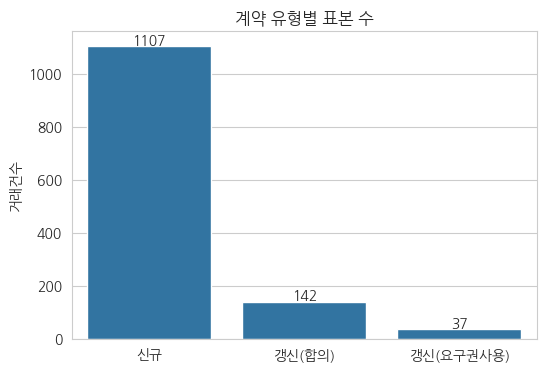

In [9]:
print("=== 계약구분(신규/갱신/결측) 비율 ===")
contract_type_counts = df["계약구분"].value_counts(dropna=False)
display(contract_type_counts)

renewal_slice = df.loc[df["계약구분"] == "갱신", "갱신요구권사용"]

print("\n=== 갱신계약 중 갱신요구권사용 개수 ===")
display(renewal_slice.value_counts(dropna=False))

n_total = len(df)
n_new = contract_type_counts.get("신규", 0)
n_renewal_total = contract_type_counts.get("갱신", 0)
n_renewal_used = (renewal_slice == "사용").sum()
n_renewal_agreed = n_renewal_total - n_renewal_used

print("\n=== 신규 / 갱신(합의) / 갱신(요구권사용) 비율 (전체 대비) ===")
print(f"신규: {n_new}건 ({n_new / n_total * 100:.1f}%)")
print(f"갱신(합의): {n_renewal_agreed}건 ({n_renewal_agreed / n_total * 100:.1f}%)")
print(f"갱신(요구권사용): {n_renewal_used}건 ({n_renewal_used / n_total * 100:.1f}%)")

plt.figure(figsize=(6, 4))
labels = ["신규", "갱신(합의)", "갱신(요구권사용)"]
counts = [n_new, n_renewal_agreed, n_renewal_used]
sns.barplot(x=labels, y=counts)
plt.title("계약 유형별 표본 수")
plt.ylabel("거래건수")
for i, c in enumerate(counts):
    plt.text(i, c + 5, str(c), ha="center")
plt.show()



*   **전세·월세 비중** 파악




,전월세구분,거래건수
0,월세,1054
1,전세,263


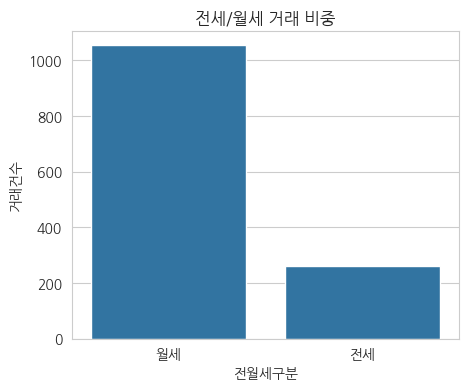

In [10]:
rent_type_counts = (
    df["전월세구분"]
    .value_counts(dropna=False)
    .rename_axis("전월세구분")
    .reset_index(name="거래건수")
)
display(rent_type_counts)

plt.figure(figsize=(5, 4))
sns.barplot(data=rent_type_counts, x="전월세구분", y="거래건수")
plt.title("전세/월세 거래 비중")
plt.show()




*   동별 표본수



,동그룹,거래건수
0,안암동,757
1,보문동,560



모든 동그룹이 표본 30건 이상입니다.


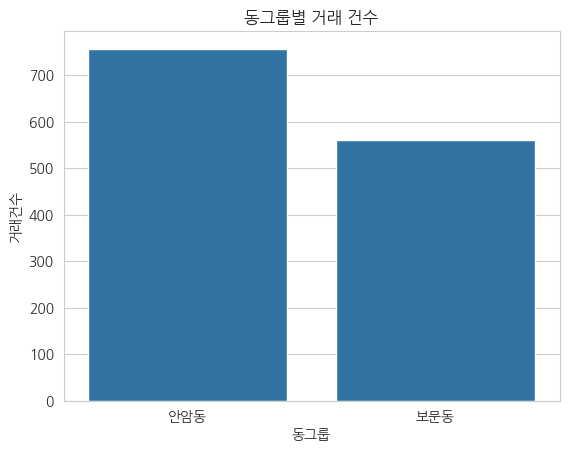

In [12]:
dong_counts = (
    df["동그룹"]
    .value_counts()
    .rename_axis("동그룹")
    .reset_index(name="거래건수")
)
display(dong_counts)

MIN_SAMPLE = 30
low_sample = dong_counts[dong_counts["거래건수"] < MIN_SAMPLE]

if len(low_sample) > 0:
    print(f"\n⚠️ 표본 {MIN_SAMPLE}건 미만인 동그룹:")
    display(low_sample)
else:
    print(f"\n모든 동그룹이 표본 {MIN_SAMPLE}건 이상입니다.")

sns.barplot(data=dong_counts, x="동그룹", y="거래건수")
plt.title("동그룹별 거래 건수")
plt.show()

# 6. 전월세 환산보증금 산출

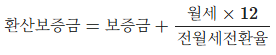

※ 한국부동산원 제공 "지역별 전월세 전환율_연립_다세대.xlsx" 파일 사용

In [15]:
from google.colab import drive

RATE_PATH = "지역별 전월세 전환율_연립_다세대.xlsx"

rate_df = pd.read_excel(RATE_PATH, header=None, skiprows=2)
header_row = pd.read_excel(RATE_PATH, header=None, nrows=1).iloc[0]
rate_df.columns = header_row

dbk_row = rate_df[rate_df.iloc[:, 2] == '동북권'].iloc[0]

rate_map = {}
for col in rate_df.columns[3:]:
    year, month = col.split('년')
    month = month.replace('월', '').strip()
    ym = f"{year.strip()}-{int(month):02d}"
    rate_map[ym] = dbk_row[col]

df["동북권_전환율(%)"] = df["계약연월"].map(rate_map)


latest_ym = max(rate_map)
n_missing = df["동북권_전환율(%)"].isna().sum()
df["동북권_전환율(%)"] = df["동북권_전환율(%)"].fillna(rate_map[latest_ym])
print(f"전환율 매칭 안 돼서 최신값({latest_ym}={rate_map[latest_ym]}%)으로 대체된 건수: {n_missing}")

df["환산보증금_만원"] = np.where(
    df["전월세구분"] == "전세",
    df["보증금_만원"],
    df["보증금_만원"] + (df["월세금_만원"] * 12) / (df["동북권_전환율(%)"] / 100)
)

print("적용 전환율: 한국부동산원 서울 동북권 월별 실제값 (성북구·동대문구 소재)")
display(
    df[["계약연월", "동북권_전환율(%)", "전월세구분", "보증금_만원", "월세금_만원", "환산보증금_만원"]]
    .sample(10, random_state=42)
)


전환율 매칭 안 돼서 최신값(2026-06=4.8%)으로 대체된 건수: 962
적용 전환율: 한국부동산원 서울 동북권 월별 실제값 (성북구·동대문구 소재)


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,계약연월,동북권_전환율(%),전월세구분,보증금_만원,월세금_만원,환산보증금_만원
261,2023-11,4.8,월세,1000,62,16500.0
991,2025-10,5.0,전세,28000,0,28000.0
554,2024-07,4.8,월세,25000,25,31250.0
49,2023-02,4.8,월세,6000,80,26000.0
857,2025-06,4.8,월세,6300,35,15050.0
1148,2026-01,5.0,월세,1000,70,17800.0
1088,2025-12,5.0,월세,2000,72,19280.0
558,2024-07,4.8,월세,1000,74,19500.0
78,2023-02,4.8,전세,22000,0,22000.0
594,2024-08,4.8,전세,28000,0,28000.0


환산보증금 기초통계


,환산보증금_만원
count,1317.000000
mean,19275.249270
std,8204.530472
min,3597.000000
10%,11186.379592
25%,14000.000000
50%,17360.000000
75%,22000.000000
90%,30720.000000
max,57500.000000


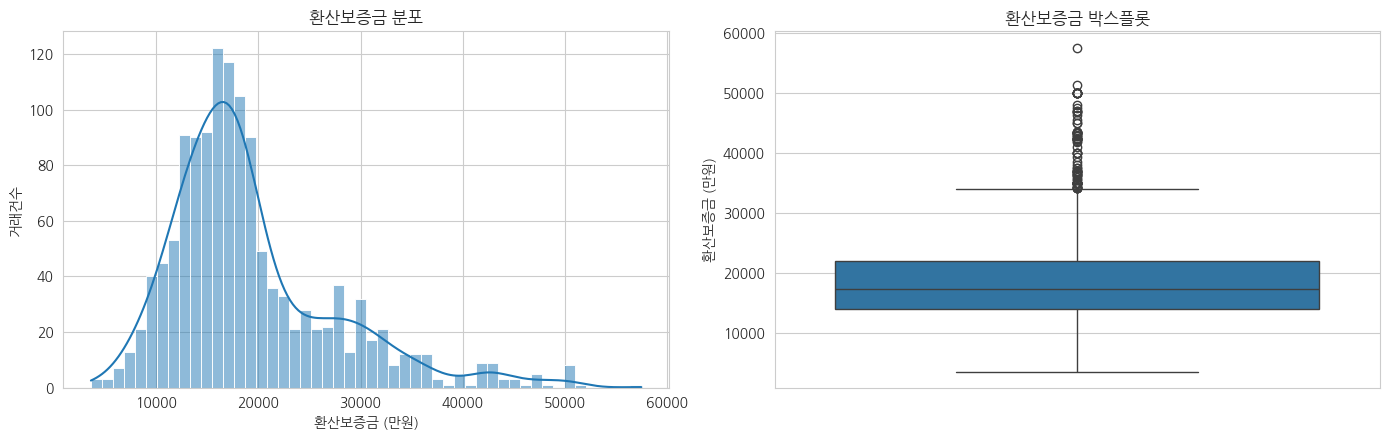

In [16]:
print("환산보증금 기초통계")
display(df["환산보증금_만원"].describe(percentiles=[.1, .25, .5, .75, .9]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(df["환산보증금_만원"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("환산보증금 분포")
axes[0].set_xlabel("환산보증금 (만원)")
axes[0].set_ylabel("거래건수")

sns.boxplot(y=df["환산보증금_만원"], ax=axes[1])
axes[1].set_title("환산보증금 박스플롯")
axes[1].set_ylabel("환산보증금 (만원)")

plt.tight_layout()
plt.show()



*   전세 vs 월세(환산) 가격 분포 비교



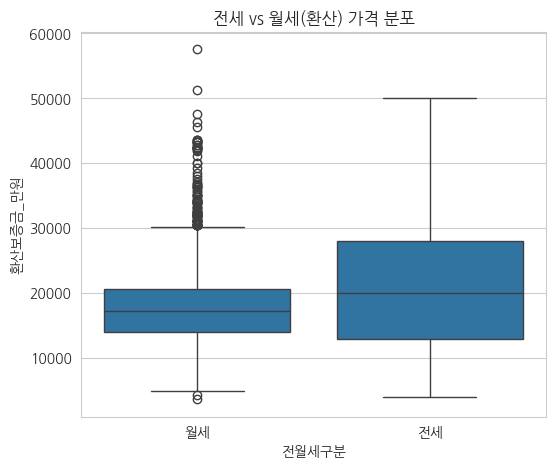

,count,mean,50%,std
전월세구분,,,,
월세,1054.0,18724.691924,17250.0,7336.506095
전세,263.0,21481.665399,20000.0,10755.576868


In [17]:

plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="전월세구분", y="환산보증금_만원")
plt.title("전세 vs 월세(환산) 가격 분포")
plt.show()

display(
    df.groupby("전월세구분")["환산보증금_만원"]
    .describe()[["count", "mean", "50%", "std"]]
)


# 7. 면적 구간 및 면적당가격 분석



1.   전용면적 분포 확인
2.   대/중/소 컷라인 설정
3.   면적당가격(㎡당 환산보증금) 만들어 비교 분석



전용면적 기초통계


,전용면적_m2
count,1317.000000
mean,29.981777
std,21.713507
min,9.300000
10%,12.680000
25%,14.160000
50%,22.450000
75%,38.070000
90%,56.168000
max,162.730000


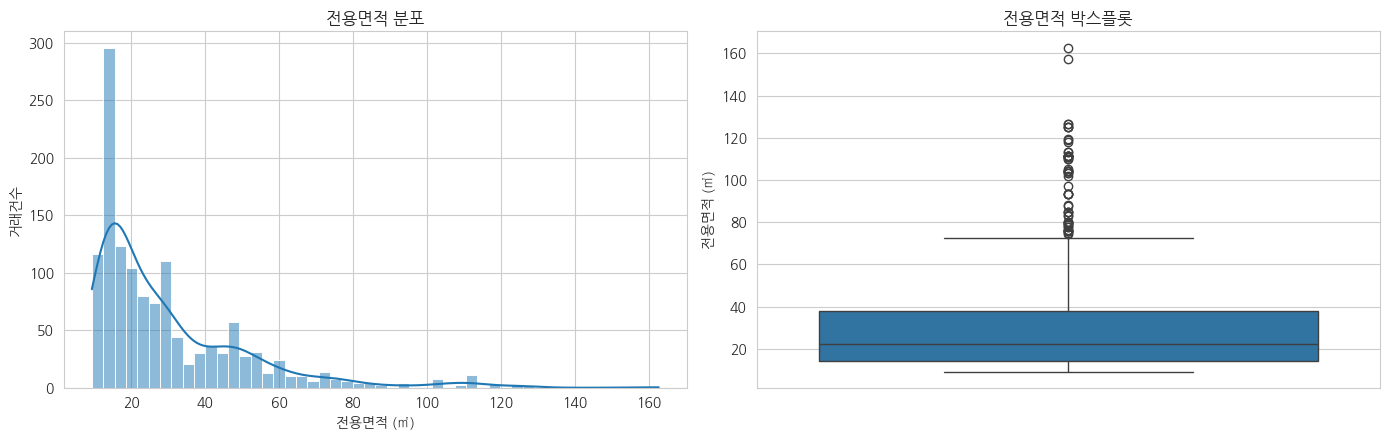

In [18]:
print("전용면적 기초통계")
display(df["전용면적_m2"].describe(percentiles=[.1, .25, .5, .75, .9]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(df["전용면적_m2"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("전용면적 분포")
axes[0].set_xlabel("전용면적 (㎡)")
axes[0].set_ylabel("거래건수")

sns.boxplot(y=df["전용면적_m2"], ax=axes[1])
axes[1].set_title("전용면적 박스플롯")
axes[1].set_ylabel("전용면적 (㎡)")

plt.tight_layout()
plt.show()

면적라벨별 거래건수


,count
면적라벨,
소형,601
중형,336
대형,380


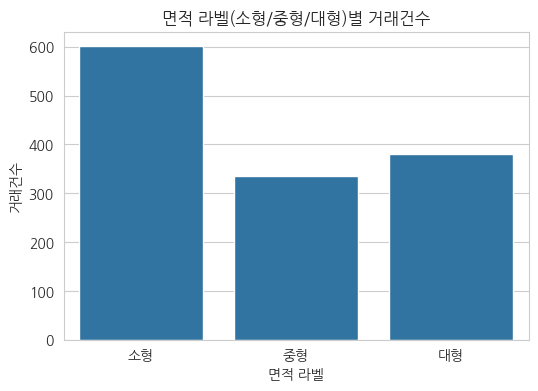

In [19]:
label_map = {
    "20㎡ 이하": "소형",
    "20㎡ 초과~33㎡ 이하": "중형",
    "33㎡ 초과": "대형",
}
df["면적라벨"] = df["면적구간"].map(label_map)

size_order = ["소형", "중형", "대형"]

print("면적라벨별 거래건수")
display(df["면적라벨"].value_counts().reindex(size_order))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="면적라벨", order=size_order)
plt.title("면적 라벨(소형/중형/대형)별 거래건수")
plt.xlabel("면적 라벨")
plt.ylabel("거래건수")
plt.show()

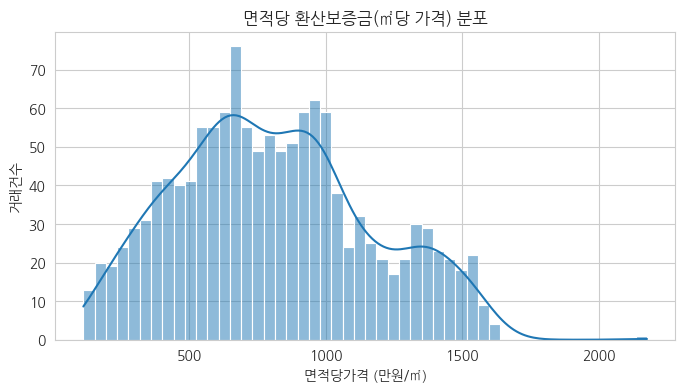

면적당가격 기초통계


,면적당가격_만원
count,1317.000000
mean,808.580225
std,354.305117
min,112.347528
1%,154.530912
5%,264.981018
25%,546.502385
50%,786.369594
75%,1027.006466
95%,1455.086304


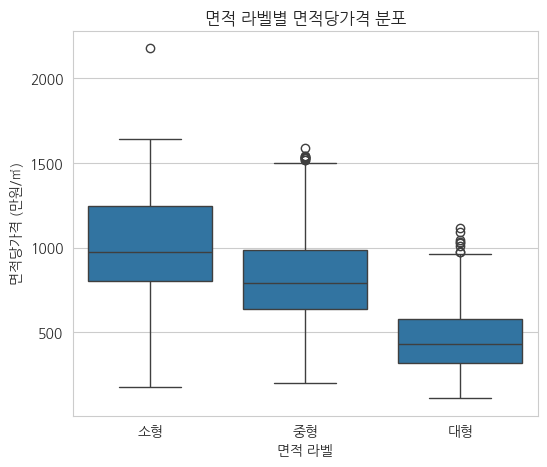

면적라벨별 면적당가격 중위값


,면적당가격_만원
면적라벨,
소형,975.378788
중형,789.356896
대형,429.305284


In [20]:
df["면적당가격_만원"] = df["환산보증금_만원"] / df["전용면적_m2"]

plt.figure(figsize=(8, 4))
sns.histplot(df["면적당가격_만원"], bins=50, kde=True)
plt.title("면적당 환산보증금(㎡당 가격) 분포")
plt.xlabel("면적당가격 (만원/㎡)")
plt.ylabel("거래건수")
plt.show()

print("면적당가격 기초통계")
display(df["면적당가격_만원"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

# 면적라벨(소/중/대)별 면적당가격 비교
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="면적라벨", y="면적당가격_만원", order=size_order)
plt.title("면적 라벨별 면적당가격 분포")
plt.xlabel("면적 라벨")
plt.ylabel("면적당가격 (만원/㎡)")
plt.show()

print("면적라벨별 면적당가격 중위값")
display(df.groupby("면적라벨")["면적당가격_만원"].median().reindex(size_order))

# 8. 이상치 탐지 및 처리

**방법: 그룹별 로그변환 Z-score**

동그룹(안암동/보문동) × 면적라벨(소형/중형/대형) 교차 그룹별로 면적당가격을 로그변환(log1p)한 뒤 Z-score를 계산해, 그룹 내 평균에서 일정 기준 이상 벗어난 값을 이상치로 판단함.

In [24]:
# 1. 로그변환
df["log_면적당가격"] = np.log1p(df["면적당가격_만원"])

group_cols = ["면적라벨", "동그룹"]

# 2. 그룹별 표본수 확인
group_sizes = df.groupby(group_cols).size().reset_index(name="n")
display(group_sizes.sort_values("n"))

MIN_GROUP_N = 20
small_groups = group_sizes[group_sizes["n"] < MIN_GROUP_N]
if len(small_groups) > 0:
    print(f"⚠️ 표본 {MIN_GROUP_N}건 미만 그룹 {len(small_groups)}개 — 이 그룹들은 z-score 해석에 유의")
    display(small_groups)

# 3. 그룹별 Z-score 계산
def safe_zscore(x):
    std = x.std(ddof=0)
    if std == 0 or np.isnan(std):
        return pd.Series(0, index=x.index)  # 그룹 내 값이 동일하면 이상치 아님으로 처리
    return (x - x.mean()) / std

df["z_면적당가격"] = df.groupby(group_cols)["log_면적당가격"].transform(safe_zscore)

# 4. 이상치 후보 표시
df["이상치후보"] = df["z_면적당가격"].abs() > 3

print(f"\n이상치 후보: {df['이상치후보'].sum():,}건 ({df['이상치후보'].mean()*100:.2f}%)")

# 5. 이상치 후보 상세 확인용 테이블
check_cols = ["주소", "면적라벨", "동그룹", "전용면적_m2",
              "환산보증금_만원", "면적당가격_만원", "z_면적당가격"]
check_cols = [c for c in check_cols if c in df.columns]


outlier_candidates = df.loc[df["이상치후보"], check_cols]


# 6. 이상치 제거 → 모델링용 df_clean 생성
df_clean = df[~df["이상치후보"]].reset_index(drop=True)

print(f"\n원본: {len(df):,}행 → 이상치 제거 후: {len(df_clean):,}행 "
      f"(제거: {len(df) - len(df_clean):,}행, "
      f"{(len(df) - len(df_clean)) / len(df) * 100:.2f}%)")

# 검토용으로 CSV 저장
outlier_candidates.to_csv("이상치후보_검토용.csv", index=False, encoding="utf-8-sig")

,면적라벨,동그룹,n
5,중형,안암동,109
2,소형,보문동,166
0,대형,보문동,167
1,대형,안암동,213
4,중형,보문동,227
3,소형,안암동,435



이상치 후보: 10건 (0.76%)

원본: 1,317행 → 이상치 제거 후: 1,307행 (제거: 10행, 0.76%)


# 데이터 저장

In [26]:
df_clean.to_csv("dataset_preprocessed_ML1조.csv", index=False, encoding="utf-8-sig")
print(f"저장 완료: {len(df_clean):,}행")


저장 완료: 1,307행
